# Acrobot Continued: Deep Q-Learning (DQN) + Hyperparameter Sweep
This notebook picks up where **`acrobot_gymnasium_basics.ipynb`** left off.

That notebook built a tabular Q-learning agent on a *discretized* version of Acrobot's continuous observation space, and was honest about its main weakness:

> tabular Q-learning with hand-picked bins is a relatively weak tool for continuous-control problems like this.

Here we address that weakness directly, and combine it with a second goal: a **hyperparameter sweep**, but this time over a neural network's hyperparameters instead of just bin counts.

**What we'll cover:**
1. Why a neural network fixes the discretization problem
2. The three building blocks of DQN: a Q-network, a replay buffer, and a target network
3. Implementing a `DQNAgent` from scratch in PyTorch
4. A quick sanity-check training run
5. A hyperparameter sweep over learning rate and discount factor (gamma) — the direct analogues of `alpha` and `gamma` from the tabular notebook
6. Picking the best config and training it for longer
7. Evaluating and watching the trained agent

**A note on runtime:** DQN needs many more environment steps than you might expect, and each step now involves a small neural-network update instead of a single dictionary lookup. The sweep trains 4 agents; the final agent trains for longer. On a normal laptop CPU this notebook should take somewhere in the range of 10-25 minutes end to end. Every episode count is a variable near the top of its cell, so if you want a faster first pass, turn `SWEEP_EPISODES` and `FINAL_EPISODES` down — you'll get noisier results, but you'll see the whole notebook run quickly.


## 1. Installation
Same as before, plus **PyTorch** for the neural network.


In [ ]:
# Run this once. torch is the neural network library we'll use for the Q-network.
# %pip install "gymnasium[classic-control]" torch --quiet


## 2. Imports and Reproducibility
A few new imports compared to the tabular notebook:
- `torch`, `torch.nn`, `torch.optim` — building and training the neural network
- `collections.deque` and `namedtuple` — the replay buffer
- `random` — sampling from the replay buffer


In [1]:
import random
from collections import deque, namedtuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import HTML
from matplotlib import animation

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## 3. Why a Neural Network Instead of a Table?
In the tabular notebook, we turned Acrobot's 6 continuous numbers into a finite set of bins so we could use a plain dictionary as our Q-table. That works, but it throws information away: two very different observations that happen to land in the same bin get treated as *identical* by the agent, no matter how different their actual physics are.

A neural network sidesteps this. Instead of looking up `Q[state][action]` in a table, we train a function

```
Q(state, action; weights) ≈ expected future reward
```

where `state` is fed in as its raw 6 continuous numbers (no binning at all), and the network **generalizes** — nearby states naturally produce similar Q-values, because that's what a smooth function does. This combination of Q-learning with a neural network function approximator is exactly what's called **Deep Q-Learning (DQN)**.

Two extra tricks make DQN training stable, and we'll implement both:
- **Experience replay** — store past transitions and train on random batches of them, rather than only the most recent step. This breaks the strong correlation between consecutive experiences, which would otherwise destabilize training.
- **A target network** — a second, slow-moving copy of the Q-network, used only to compute the "next state" value in the Q-learning update. Without it, the network would be chasing a constantly-shifting target (since the same network produces both today's prediction and today's target), which tends to make training diverge.


## 4. The Q-Network
A small multi-layer perceptron (MLP): 6 input numbers (the raw observation) in, 3 numbers out (one Q-value per action).

### Python refresher: subclassing `nn.Module`
Every PyTorch network is a class that inherits from `nn.Module` and defines a `forward()` method describing how input data flows through it. This is the same "class with methods" pattern you'd use for any custom Python object — PyTorch just expects specific method names (`__init__` and `forward`) so it knows how to run and train the network.


In [2]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)


## 5. The Replay Buffer
A fixed-size memory of past `(state, action, reward, next_state, done)` transitions. We push new transitions in as they happen, and randomly sample a batch out of it to train on.

### Python refresher: `deque` and `namedtuple`
- `deque(maxlen=N)` behaves like a list, but automatically drops the oldest item once it reaches `N` items — perfect for a fixed-size memory.
- `namedtuple` gives us a lightweight object with named fields (`transition.state`, `transition.reward`, ...) instead of an unlabeled tuple `(s, a, r, s2, d)` where it's easy to lose track of which position means what.


In [3]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])


class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))  # transpose list-of-tuples into tuple-of-lists

    def __len__(self):
        return len(self.buffer)


## 6. The DQN Agent
This class ties the Q-network, target network, and replay buffer together, with three main jobs:
- `select_action` — epsilon-greedy, same idea as the tabular notebook, but now querying the network instead of a dictionary
- `store` — save a transition to the replay buffer
- `train_step` — sample a batch from the buffer and run one gradient-descent update on the Q-network

The target network is *not* trained directly — we periodically copy the Q-network's weights into it via `sync_target()`, which the training loop calls every few episodes.


In [4]:
class DQNAgent:
    def __init__(self, obs_dim, n_actions, hidden_size=128, lr=1e-3, gamma=0.99,
                 buffer_capacity=50_000, batch_size=64):
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size

        self.q_network = QNetwork(obs_dim, n_actions, hidden_size)
        self.target_network = QNetwork(obs_dim, n_actions, hidden_size)
        self.sync_target()
        self.target_network.eval()  # target network is never trained directly

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_capacity)

    def sync_target(self):
        """Copy the Q-network's weights into the target network."""
        self.target_network.load_state_dict(self.q_network.state_dict())

    def select_action(self, state, epsilon):
        if random.random() < epsilon:
            return random.randrange(self.n_actions)  # explore
        with torch.no_grad():
            state_t = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
            q_values = self.q_network(state_t)
        return int(torch.argmax(q_values, dim=1).item())  # exploit

    def store(self, state, action, reward, next_state, done):
        self.buffer.push(state, action, reward, next_state, done)

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return None  # not enough experience yet

        batch = self.buffer.sample(self.batch_size)

        states = torch.as_tensor(np.array(batch.state), dtype=torch.float32)
        actions = torch.as_tensor(batch.action, dtype=torch.int64).unsqueeze(1)
        rewards = torch.as_tensor(batch.reward, dtype=torch.float32).unsqueeze(1)
        next_states = torch.as_tensor(np.array(batch.next_state), dtype=torch.float32)
        dones = torch.as_tensor(batch.done, dtype=torch.float32).unsqueeze(1)

        # Q-values the network currently predicts for the actions actually taken
        q_values = self.q_network(states).gather(1, actions)

        # Q-learning target, using the target network for stability
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(dim=1, keepdim=True)[0]
            td_target = rewards + self.gamma * next_q_values * (1.0 - dones)

        loss = nn.functional.mse_loss(q_values, td_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.item()


## 7. The Training Loop
Structurally similar to the tabular notebook's training loop: reset, act, step, learn, repeat. Two differences:
- No `discretize()` call; the raw observation goes straight into the network.
- A `target_update_freq`; every this-many episodes, we sync the target network.

We wrap this in a function so we can call it repeatedly during the sweep, each time with a fresh agent and a fresh environment.


In [5]:
def moving_average(x, window=20):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    cumsum = np.cumsum(np.insert(x, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / float(window)


def train_dqn(agent, episodes=200, max_steps=500, epsilon_start=1.0, epsilon_min=0.05,
              epsilon_decay=0.995, target_update_freq=10, seed=None, verbose_every=None):
    env = gym.make("Acrobot-v1")
    epsilon = epsilon_start
    episode_rewards = []

    for ep in range(episodes):
        obs, info = env.reset(seed=seed if ep == 0 else None)
        total_reward = 0

        for t in range(max_steps):
            action = agent.select_action(obs, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.store(obs, action, reward, next_obs, done)
            agent.train_step()

            obs = next_obs
            total_reward += reward
            if done:
                break

        episode_rewards.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (ep + 1) % target_update_freq == 0:
            agent.sync_target()

        if verbose_every and (ep + 1) % verbose_every == 0:
            recent_avg = np.mean(episode_rewards[-verbose_every:])
            print(f"  Episode {ep + 1}/{episodes} | epsilon={epsilon:.3f} | avg reward (last {verbose_every}): {recent_avg:.1f}")

    env.close()
    return episode_rewards


## 8. Quick Sanity-Check Run
Before committing to a full sweep, let's train one agent for a small number of episodes, just to confirm the code runs end to end and the loss is doing *something* sensible. This is not meant to produce a good agent; 60 episodes is far too few for that.


Observation dimension: 6, number of actions: 3
  Episode 20/60 | epsilon=0.905 | avg reward (last 20): -500.0
  Episode 40/60 | epsilon=0.818 | avg reward (last 20): -500.0
  Episode 60/60 | epsilon=0.740 | avg reward (last 20): -500.0


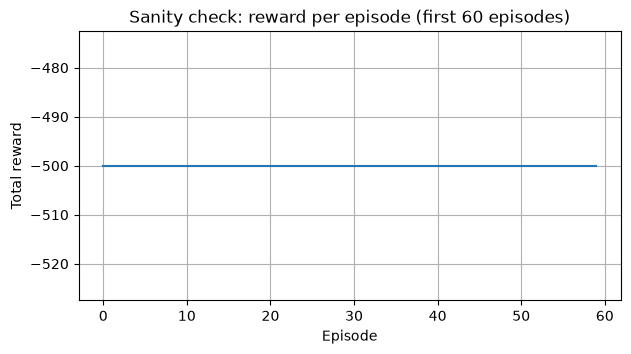

In [6]:
_env = gym.make("Acrobot-v1")
OBS_DIM = _env.observation_space.shape[0]
N_ACTIONS = _env.action_space.n
_env.close()

print(f"Observation dimension: {OBS_DIM}, number of actions: {N_ACTIONS}")

torch.manual_seed(SEED)
sanity_agent = DQNAgent(obs_dim=OBS_DIM, n_actions=N_ACTIONS)
sanity_rewards = train_dqn(sanity_agent, episodes=60, seed=SEED, verbose_every=20)

plt.figure(figsize=(7, 3.5))
plt.plot(sanity_rewards)
plt.title("Sanity check: reward per episode (first 60 episodes)")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.grid(True)
plt.show()

## 9. Hyperparameter Sweep
Now the second half of the plan. The tabular notebook's wrap-up suggested experimenting with `alpha`, `gamma`, and `epsilon_decay` by hand. Here we do the same thing more systematically, sweeping over the two hyperparameters with the most direct analogues in the tabular notebook:

- **`lr`** (learning rate): DQN's version of the tabular notebook's `alpha`. Controls how big a step the network takes on each update.
- **`gamma`** (discount factor): the exact same concept as before; how much future reward is worth relative to immediate reward.

We train a separate agent from scratch for each of the 4 combinations below, using the same number of episodes for a fair comparison.


In [ ]:
SWEEP_EPISODES = 200  # lower this for a faster (noisier) first pass

sweep_configs = [
    {"lr": 1e-3, "gamma": 0.99},
    {"lr": 1e-3, "gamma": 0.95},
    {"lr": 5e-4, "gamma": 0.99},
    {"lr": 5e-4, "gamma": 0.95},
]

sweep_results = []  # list of {"label", "cfg", "rewards"}

for cfg in sweep_configs:
    label = f"lr={cfg['lr']}, gamma={cfg['gamma']}"
    print(f"Training config: {label}")

    torch.manual_seed(SEED)
    agent = DQNAgent(obs_dim=OBS_DIM, n_actions=N_ACTIONS, lr=cfg["lr"], gamma=cfg["gamma"])
    rewards = train_dqn(agent, episodes=SWEEP_EPISODES, seed=SEED, verbose_every=50)

    sweep_results.append({"label": label, "cfg": cfg, "rewards": rewards})
    print()


Training config: lr=0.001, gamma=0.99
  Episode 50/200 | epsilon=0.778 | avg reward (last 50): -496.8
  Episode 100/200 | epsilon=0.606 | avg reward (last 50): -492.6
  Episode 150/200 | epsilon=0.471 | avg reward (last 50): -405.6
  Episode 200/200 | epsilon=0.367 | avg reward (last 50): -310.3

Training config: lr=0.001, gamma=0.95
  Episode 50/200 | epsilon=0.778 | avg reward (last 50): -499.6
  Episode 100/200 | epsilon=0.606 | avg reward (last 50): -475.3
  Episode 150/200 | epsilon=0.471 | avg reward (last 50): -433.0
  Episode 200/200 | epsilon=0.367 | avg reward (last 50): -339.8

Training config: lr=0.0005, gamma=0.99
  Episode 50/200 | epsilon=0.778 | avg reward (last 50): -500.0
  Episode 100/200 | epsilon=0.606 | avg reward (last 50): -472.5
  Episode 150/200 | epsilon=0.471 | avg reward (last 50): -403.0
  Episode 200/200 | epsilon=0.367 | avg reward (last 50): -255.2

Training config: lr=0.0005, gamma=0.95
  Episode 50/200 | epsilon=0.778 | avg reward (last 50): -495.0
  

## 10. Comparing the Sweep Results
Plotting all four smoothed learning curves on one axis makes it easy to see which combination of `lr` and `gamma` learned fastest and topped out highest.


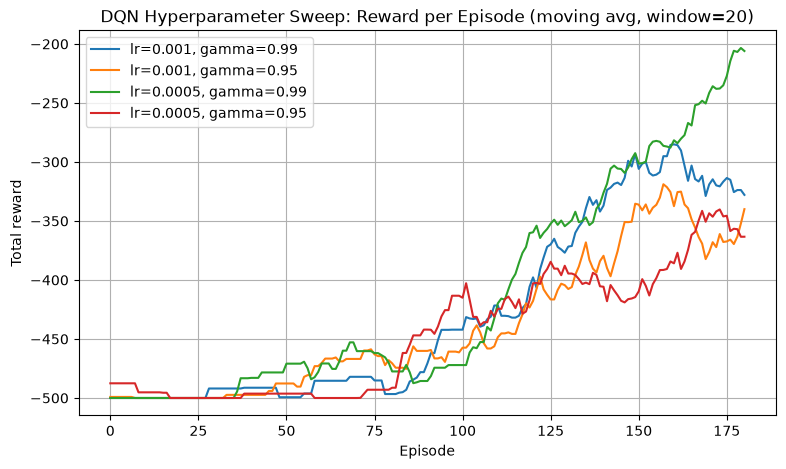

Final performance (average of last 20 episodes) per config:
  lr=0.001, gamma=0.99: -327.9
  lr=0.001, gamma=0.95: -340.0
  lr=0.0005, gamma=0.99: -206.0
  lr=0.0005, gamma=0.95: -363.4


In [8]:
plt.figure(figsize=(9, 5))
for result in sweep_results:
    smoothed = moving_average(result["rewards"], window=20)
    plt.plot(smoothed, label=result["label"])
plt.title("DQN Hyperparameter Sweep: Reward per Episode (moving avg, window=20)")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.legend()
plt.grid(True)
plt.show()

print("Final performance (average of last 20 episodes) per config:")
for result in sweep_results:
    final_avg = np.mean(result["rewards"][-20:])
    print(f"  {result['label']}: {final_avg:.1f}")


## 11. Training the Best Config for Longer
Whichever config had the highest average reward over its last 20 episodes gets picked automatically, then retrained from scratch for more episodes — the short sweep runs are enough to *compare* configs, but not enough to fully train a final agent.


In [ ]:
FINAL_EPISODES = 500  # lower this for a faster (weaker) final agent

best_result = max(sweep_results, key=lambda r: np.mean(r["rewards"][-20:]))
best_cfg = best_result["cfg"]
print(f"Best config from the sweep: {best_result['label']}")

torch.manual_seed(SEED)
final_agent = DQNAgent(obs_dim=OBS_DIM, n_actions=N_ACTIONS, lr=best_cfg["lr"], gamma=best_cfg["gamma"])
final_rewards = train_dqn(final_agent, episodes=FINAL_EPISODES, seed=SEED, verbose_every=50)


In [ ]:
smoothed_final = moving_average(final_rewards, window=20)

plt.figure(figsize=(8, 4))
plt.plot(final_rewards, alpha=0.2, label="raw reward")
plt.plot(smoothed_final, color="orange", label="moving average (window=20)")
plt.title(f"Final DQN Agent ({best_result['label']}): Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.grid(True)
plt.legend()
plt.show()


## 12. Evaluating the Trained Agent
Same idea as the tabular notebook: run the **greedy** policy (`epsilon=0`, no exploration) on fresh episodes and see how it does.


In [ ]:
def evaluate_dqn(agent, episodes=20, max_steps=500):
    env = gym.make("Acrobot-v1")
    rewards = []
    successes = 0
    for _ in range(episodes):
        obs, info = env.reset()
        total_reward = 0
        for _ in range(max_steps):
            action = agent.select_action(obs, epsilon=0.0)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            if terminated or truncated:
                if terminated:
                    successes += 1
                break
        rewards.append(total_reward)
    env.close()
    return np.mean(rewards), successes / episodes


avg_reward, success_rate = evaluate_dqn(final_agent)
print(f"Average reward over evaluation episodes: {avg_reward:.1f}")
print(f"Success rate (reached the target height before timing out): {success_rate * 100:.0f}%")


## 13. Watching the Trained DQN Agent
Same animation approach as the tabular notebook, driven by `final_agent`'s greedy policy instead of a Q-table lookup.


In [ ]:
def collect_dqn_episode_frames(agent, seed=SEED, max_steps=500):
    render_env = gym.make("Acrobot-v1", render_mode="rgb_array")
    obs, info = render_env.reset(seed=seed)

    frames = [render_env.render()]
    for _ in range(max_steps):
        action = agent.select_action(obs, epsilon=0.0)
        obs, reward, terminated, truncated, info = render_env.step(action)
        frames.append(render_env.render())
        if terminated or truncated:
            break

    render_env.close()
    return frames


def make_animation(frames, title=""):
    fig, ax = plt.subplots()
    ax.axis("off")
    if title:
        ax.set_title(title)
    img = ax.imshow(frames[0])

    def update(i):
        img.set_data(frames[i])
        return [img]

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=40, blit=True)
    plt.close(fig)
    return anim


dqn_frames = collect_dqn_episode_frames(final_agent)
print(f"Collected {len(dqn_frames)} frames from the trained DQN agent.")

dqn_anim = make_animation(dqn_frames, title="Trained DQN agent (greedy policy)")
HTML(dqn_anim.to_jshtml())


## Wrap-up & Next Steps

**What we covered:**
- Why raw continuous observations plus a neural network sidesteps the information loss from discretization
- The three core DQN components: a Q-network, an experience replay buffer, and a target network
- A from-scratch PyTorch implementation of a `DQNAgent`
- A hyperparameter sweep over learning rate and gamma, directly comparable to the tabular notebook's `alpha`/`gamma`
- Training the best config for longer, evaluating it, and watching it in action

**A few honest notes:**
- 500 episodes is a modest training budget for DQN on Acrobot — if the agent isn't reliably reaching the target, more episodes (or a slower epsilon decay) usually helps before anything more exotic does.
- The sweep here only covers 4 combinations of 2 hyperparameters. Real sweeps often also vary network size, batch size, target-update frequency, and buffer capacity — feel free to extend `sweep_configs` with more entries or more keys.
- Unlike the tabular Q-table, this agent's weights don't have an obvious "print it and look at it" form — this is a real trade-off of function approximation: better generalization, less interpretability.

**Where to go from here:**
- Compare this DQN agent's learning curve and final evaluation numbers directly against the tabular Q-learning agent from the first notebook — same environment, two very different approaches.
- Try **Double DQN** (a small change to the target calculation that reduces Q-value overestimation) or **Dueling DQN** (a small architecture change that separates state-value and action-advantage estimates).
- Once comfortable with this from-scratch version, compare it against a tuned implementation from **Stable-Baselines3** — a good way to sanity-check your own code and see how much a well-tuned implementation improves on a first pass.
